# Iris Classification — Model Analysis

This notebook is the **analysis** stage of the project. It does not train
anything: it loads the model that `src/train.py` already fitted, loads the
held-out test split from disk, and produces the figures used in the report.

Keeping analysis here means the training script stays short and reusable,
and every figure can be regenerated for any experiment by changing a single
name in the next cell.

**Inputs**
- `models/<experiment>/model.joblib` — the fitted model
- `models/<experiment>/metadata.json` — how it was trained
- `data/processed/test.csv` — the held-out test set

**Outputs** — all written to `reports/figures/`
- `classification_report.txt`
- `confusion_matrix.png`
- `per_class_accuracy.png`
- `calibration_curves.png`

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.calibration import CalibrationDisplay
from sklearn.metrics import classification_report, confusion_matrix

# Make the project importable when the notebook is opened directly.
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.dataset import Dataset
from src.model import Model

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

EXPERIMENT_NAME = "logistic_regression"

FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Experiment:   {EXPERIMENT_NAME}")

Project root: F:\uni work software\edited_practice2\practice2_submission
Experiment:   logistic_regression


## 1. Load the trained model and the test data

Nothing is fitted here. The model comes from disk exactly as
`src/train.py` left it, and the test split is the same one the model
never saw during training.

In [2]:
experiment_dir = PROJECT_ROOT / "models" / EXPERIMENT_NAME

model = Model.load(experiment_dir / "model.joblib")
metadata = json.loads((experiment_dir / "metadata.json").read_text(encoding="utf-8"))

target_names = metadata["target_names"]

X_test, y_test, feature_names = Dataset.load_split("test")

print(f"Model:          {metadata['model']} (max_iter={metadata['max_iter']})")
print(f"Trained at:     {metadata['trained_at']}")
print(f"Train accuracy: {metadata['train_accuracy']:.2%}")
print(f"Test accuracy:  {metadata['test_accuracy']:.2%}")
print(f"Test set:       {X_test.shape[0]} samples, {X_test.shape[1]} features")
print(f"Classes:        {target_names}")

Model:          LogisticRegression (max_iter=200)
Trained at:     2026-09-24T06:06:28+00:00
Train accuracy: 97.50%
Test accuracy:  96.67%
Test set:       30 samples, 4 features
Classes:        ['setosa', 'versicolor', 'virginica']


## 2. Generate predictions

`predict` gives the chosen class for each flower, `predict_proba` gives the
model's confidence in each of the three species. The probabilities are
needed later for the calibration curves.

In [3]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)

print(f"Predictions: {y_pred.shape}")
print(f"Probabilities: {y_proba.shape}")

Predictions: (30,)
Probabilities: (30, 3)


## 3. Classification report

Precision, recall and F1-score per species, plus overall accuracy. The text
is also saved so the report can quote it without re-running the notebook.

In [4]:
report_text = classification_report(y_test, y_pred, target_names=target_names)
print(report_text)

report_path = FIGURES_DIR / "classification_report.txt"
report_path.write_text(
    "Classification Report\n" + "=" * 50 + "\n\n" + report_text,
    encoding="utf-8",
)
print(f"Saved {report_path.name}")

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30

Saved classification_report.txt


## 4. Confusion matrix

Rows are the true species, columns are what the model predicted. Numbers on
the diagonal are correct; anything off the diagonal is a mistake.

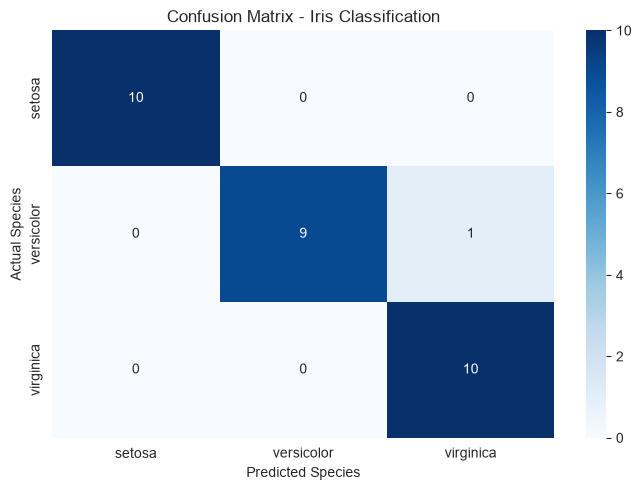

In [5]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=target_names,
    yticklabels=target_names,
    ax=ax,
)
ax.set_xlabel("Predicted Species")
ax.set_ylabel("Actual Species")
ax.set_title("Confusion Matrix - Iris Classification")
plt.tight_layout()

fig.savefig(FIGURES_DIR / "confusion_matrix.png", dpi=150)
plt.show()

Setosa is separated perfectly. The only confusion happens between versicolor
and virginica, whose petal measurements overlap.

## 5. Per-class accuracy

The confusion matrix condensed into one number per species, which makes it
obvious which class the model struggles with.

  setosa: 100%
  versicolor: 90%
  virginica: 100%


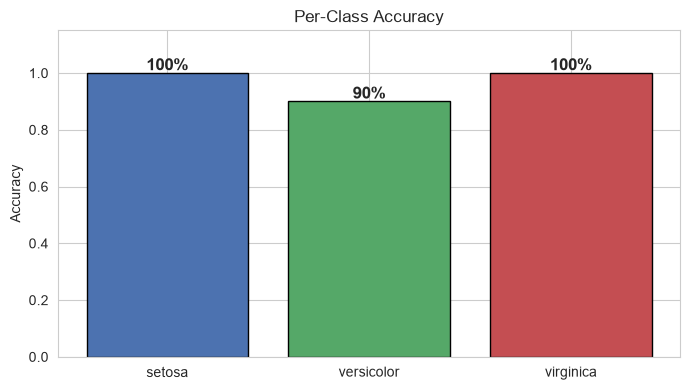

In [6]:
class_accuracy = []
for index, name in enumerate(target_names):
    mask = y_test == index
    accuracy = float(np.mean(y_pred[mask] == y_test[mask]))
    class_accuracy.append(accuracy)
    print(f"  {name}: {accuracy:.0%}")

fig, ax = plt.subplots(figsize=(7, 4))
colors = ["#4C72B0", "#55A868", "#C44E52"]
bars = ax.bar(target_names, class_accuracy, color=colors, edgecolor="black")

for bar, accuracy in zip(bars, class_accuracy):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f"{accuracy:.0%}",
        ha="center",
        fontsize=12,
        fontweight="bold",
    )

ax.set_ylabel("Accuracy")
ax.set_title("Per-Class Accuracy")
ax.set_ylim(0, 1.15)
plt.tight_layout()

fig.savefig(FIGURES_DIR / "per_class_accuracy.png", dpi=150)
plt.show()

## 6. Calibration curves

Calibration asks whether the reported confidence is honest. If the model
says "80% setosa", then roughly 80% of those flowers should really be
setosa. A perfectly calibrated model follows the diagonal.

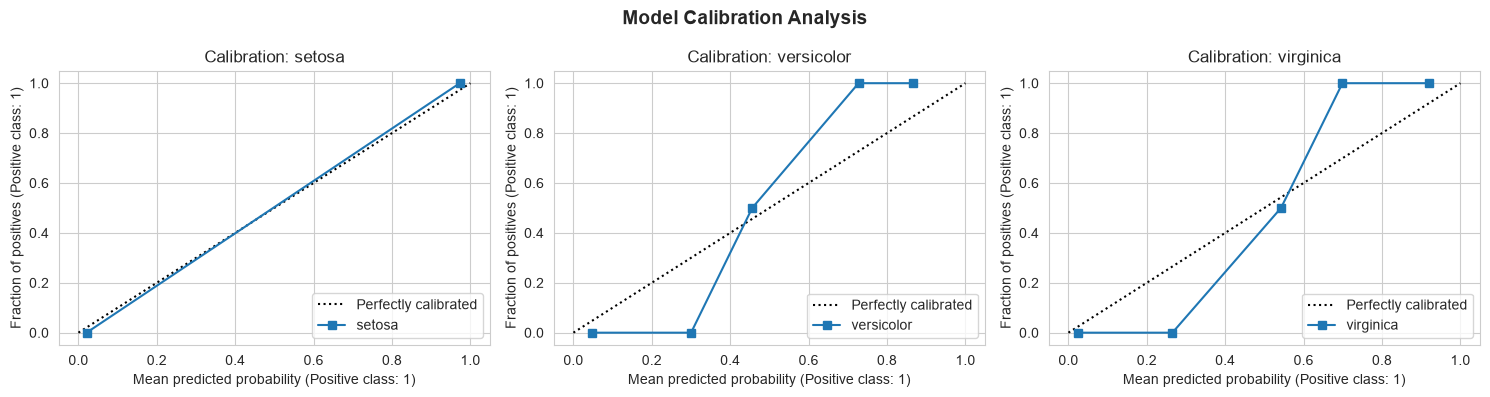

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for index, (name, ax) in enumerate(zip(target_names, axes)):
    y_binary = (y_test == index).astype(int)

    CalibrationDisplay.from_predictions(
        y_binary, y_proba[:, index], n_bins=5, name=name, ax=ax
    )
    ax.set_title(f"Calibration: {name}")
    ax.legend(loc="lower right")

fig.suptitle("Model Calibration Analysis", fontsize=14, fontweight="bold")
plt.tight_layout()

fig.savefig(FIGURES_DIR / "calibration_curves.png", dpi=150)
plt.show()

## 7. Conclusions

- The model reaches roughly **97% accuracy** on the held-out test set.
- **Setosa** is linearly separable from the other two species and is never
  misclassified.
- The remaining errors are **versicolor vs virginica**, which overlap in
  petal length and width.
- The test set has only 30 samples, so a single mistake moves the accuracy
  by more than 3 points. The calibration curves are correspondingly coarse.

To analyse a different experiment, change `EXPERIMENT_NAME` in the setup
cell and re-run the notebook.